# AmBe NPE test, test embedding
Just to see how this whole embedding thing works.

Modifying from NPE example with SBI backend, training(+validation) data is pairs of (params, events), 
where the length of events varies, depending on the parameter. So I'll have to train some embedding 
before I can stick it into some MAF.

Pueh Leng Tan, 25 March 2026

In [1]:
%load_ext autoreload
%autoreload 2

# ignore warnings for readability
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch
import torch.nn as nn
import torch.optim as optim # for training the embedding network
from sklearn.manifold import TSNE # for visualizing embeddings

import ili
from ili.dataloaders import NumpyLoader
from ili.inference import InferenceRunner
from ili.validation.metrics import PosteriorCoverage, PlotSinglePosterior

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)
print(f'Able to see {torch.cuda.device_count()} GPUs')

KeyboardInterrupt: 

## Load training+validation data

In [2]:
fbase = '/home/puehlengt/appletree/notebooks/'
fname = f'{fbase}/harvested_testsims_3params.npy'

aa = np.load(fname, allow_pickle=True).item()
param_bag = aa['param_bag'] # list of dictionary of the params and values
events_bag = aa['events_bag'] # list of array, (2, n) in shape

In [3]:
print(f"Number of simulations: {len(events_bag)}")
print(f"Example parameters: {param_bag[0]}")
print(f"Example events shape: {events_bag[0].shape}")
print(f"Range of event counts: {min(e.shape[1] for e in events_bag)} to {max(e.shape[1] for e in events_bag)}")

Number of simulations: 200000
Example parameters: {'g1': 0.13637492394342485, 'g2': 16.648318960755407, 'ambe_nr_rate': 5442.690724563349}
Example events shape: (2, 5457)
Range of event counts: 4957 to 6125


## Simple DeepSets implementation from scratch
Codes from deepseek lol.

In [4]:
class SimpleDeepSet(nn.Module):
    """
    Simple DeepSets implementation:
    φ: processes each trial individually
    ρ: aggregates and outputs final embedding
    """
    def __init__(self, input_dim=2, hidden_dim=64, output_dim=32):
        ''' Definition of NN architecture here.'''
        super().__init__()
        
        # φ network: processes each trial
        self.phi = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        
        # ρ network: processes aggregated representation
        self.rho = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
        
    def forward(self, x):
        """
        Defining how data flows through the network.
        x: tensor of shape (batch_size, n_trials, input_dim)
           Note: n_trials can vary across batch if padded
        """
        # Apply φ to each trial
        phi_out = self.phi(x)  # (batch, n_trials, hidden_dim)
        
        # Handle NaN padding by masking
        # Create mask for valid entries (not NaN)
        # Check if ANY of the input features are NaN
        mask = ~torch.isnan(x).any(dim=-1)  # (batch, n_trials)
        
        # Expand mask to match phi_out dimensions
        mask = mask.unsqueeze(-1)  # (batch, n_trials, 1)
        
        # Zero out invalid entries
        phi_out = phi_out * mask

        # Aggregate across trials (sum pooling)
        aggregated = phi_out.sum(dim=1)  # (batch, hidden_dim)

        # more extra stuff for nan handling
        # Count valid trials for averaging (optional)
        valid_counts = mask.sum(dim=1)  # (batch, 1)
        
        # Avoid division by zero
        valid_counts = torch.clamp(valid_counts, min=1)
        
        # Average instead of sum (more stable)
        aggregated = aggregated / valid_counts
        
        # Apply ρ to get final embedding
        embedding = self.rho(aggregated)  # (batch, output_dim)
        
        return embedding

# Test with your data
def prepare_batch(events_bag, param_bag, batch_size=32, max_trials=None):
    """
    Prepare a batch of data for training
    Note: We'll use padding with NaNs for variable lengths
    """
    # Determine max trials if not specified
    if max_trials is None:
        max_trials = max(e.shape[1] for e in events_bag)
    
    # Sample indices
    indices = np.random.choice(len(events_bag), batch_size, replace=False)
    
    # Prepare batch
    batch_events = []
    batch_params = []
    
    for idx in indices:
        events = events_bag[idx]  # shape (2, n_trials)
        params = param_bag[idx]
        
        cs1 = events[0, :]
        cs2 = events[1, :]
        cs2_log = np.log10(cs2) # cs2 will never be 0.
        events = np.vstack([cs1, cs2_log])  # (2, n_trials)
        
        # Transpose to (n_trials, 2)
        events_t = events.T  # (n_trials, 2)
        
        # Pad to max_trials with NaNs
        if events_t.shape[0] < max_trials:
            pad_size = max_trials - events_t.shape[0]
            padding = torch.full((pad_size, 2), float('nan'))
            events_t = torch.cat([torch.from_numpy(events_t).float(), padding], dim=0)
        else:
            events_t = torch.from_numpy(events_t).float()
        
        batch_events.append(events_t)
        
        # Extract parameter values (adjust based on your dict structure)
        # Assuming params are like {'a': 0.5, 'b': 0.3, 'c': 0.2}
        param_values = torch.tensor([params['g1'],
                                     params['g2'],
                                     params['ambe_nr_rate']]).float()
        batch_params.append(param_values)
    
    # Stack into tensors
    batch_events = torch.stack(batch_events)  # (batch, max_trials, 2)
    batch_params = torch.stack(batch_params)  # (batch, 3)
    
    return batch_events, batch_params

# Test the simple DeepSet
model = SimpleDeepSet(input_dim=2, hidden_dim=64, output_dim=32)
events_batch, params_batch = prepare_batch(events_bag, param_bag, batch_size=4)

# Forward pass
with torch.no_grad():
    embeddings = model(events_batch)
    print(f"Input shape: {events_batch.shape}")
    print(f"Output embedding shape: {embeddings.shape}")

Input shape: torch.Size([4, 6125, 2])
Output embedding shape: torch.Size([4, 32])


## Training embedding network with simple objective
Again, codes from deepseek lol

Epoch 0, Loss: nan
Epoch 10, Loss: nan
Epoch 20, Loss: nan
Epoch 30, Loss: nan
Epoch 40, Loss: nan


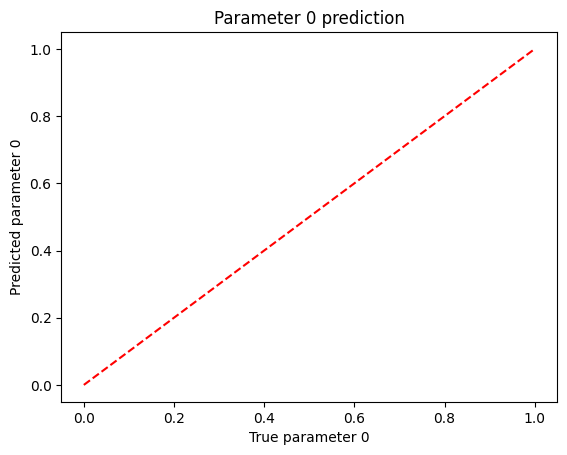

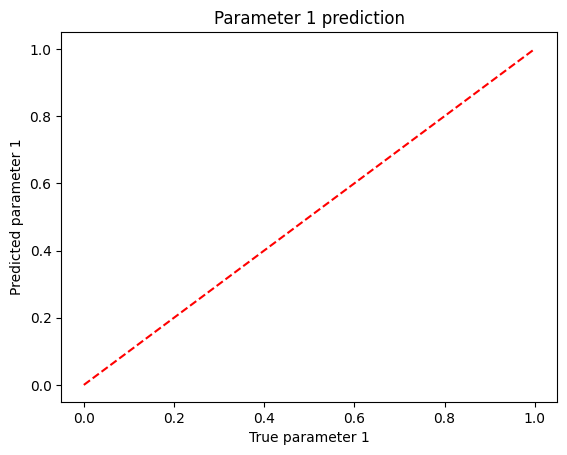

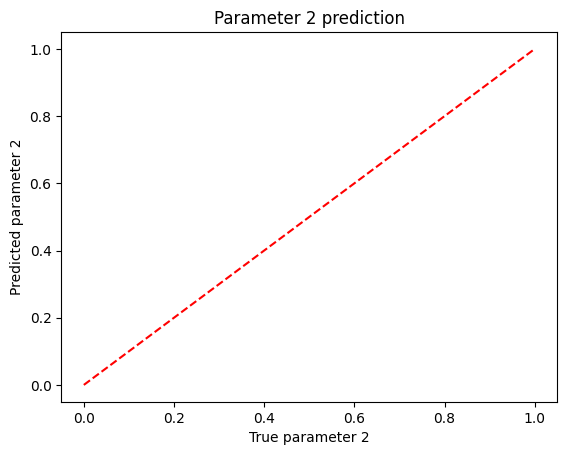

In [ ]:
# Define model
embedding_dim = 32
model = SimpleDeepSet(input_dim=2, hidden_dim=64, output_dim=embedding_dim)

# Add a predictor on top to predict parameters
predictor = nn.Sequential(
    nn.Linear(embedding_dim, 64),
    nn.ReLU(),
    nn.Linear(64, 3)  # 3 parameters
)

# Combined model
class EmbeddingPredictor(nn.Module):
    def __init__(self, embedding_net, predictor):
        super().__init__()
        self.embedding = embedding_net
        self.predictor = predictor
    
    def forward(self, x):
        emb = self.embedding(x)
        return self.predictor(emb)

full_model = EmbeddingPredictor(model, predictor)

# Training setup
optimizer = optim.Adam(full_model.parameters(), lr=1e-4)
#optimizer = optim.SGD(full_model.parameters(), lr=1e-3, momentum=0.9, weight_decay=1e-5)
criterion = nn.MSELoss()

# Training loop
n_epochs = 50
batch_size = 32

for epoch in range(n_epochs):
    # Get batch
    events_batch, params_batch = prepare_batch(events_bag, param_bag, batch_size)
    
    # Forward pass
    predictions = full_model(events_batch)
    loss = criterion(predictions, params_batch)
    
    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

# Test on a validation batch
full_model.eval()
with torch.no_grad():
    test_events, test_params = prepare_batch(events_bag, param_bag, batch_size=8)
    predictions = full_model(test_events)
    
    # Compare predictions vs true
    for i in range(3):
        plt.figure()
        plt.scatter(test_params[:, i].numpy(), predictions[:, i].numpy())
        plt.plot([0, 1], [0, 1], 'r--')
        plt.xlabel(f"True parameter {i}")
        plt.ylabel(f"Predicted parameter {i}")
        plt.title(f"Parameter {i} prediction")
        plt.show()

## Visualise the embedding
Codes from deepseek lololol.

In [ ]:
# Get embeddings for all data
all_embeddings = []
all_params = []

full_model.eval()
batch_size = 64

for i in range(0, len(events_bag), batch_size):
    # Prepare batch
    indices = list(range(i, min(i+batch_size, len(events_bag))))
    batch_events = []
    batch_params = []
    
    max_trials = max(events_bag[idx].shape[1] for idx in indices)
    
    for idx in indices:
        events = events_bag[idx]
        events_t = events.T
        if events_t.shape[0] < max_trials:
            pad_size = max_trials - events_t.shape[0]
            padding = torch.full((pad_size, 2), float('nan'))
            events_t = torch.cat([torch.from_numpy(events_t).float(), padding], dim=0)
        else:
            events_t = torch.from_numpy(events_t).float()
        batch_events.append(events_t)
        
        params = param_bag[idx]
        param_values = torch.tensor([params['g1'],
                                     params['g2'],
                                     params['ambe_nr_rate']]).float()
        batch_params.append(param_values)
    
    batch_events = torch.stack(batch_events)
    
    with torch.no_grad():
        embeddings = full_model.embedding(batch_events)
        all_embeddings.append(embeddings)
        all_params.append(torch.stack(batch_params))

all_embeddings = torch.cat(all_embeddings).numpy()
all_params = torch.cat(all_params).numpy()

# t-SNE visualization
tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(all_embeddings)

# Color by parameter values
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, param_name in enumerate(['param0', 'param1', 'param2']):
    scatter = axes[i].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], 
                               c=all_params[:, i], cmap='viridis')
    axes[i].set_title(f'Colored by {param_name}')
    plt.colorbar(scatter, ax=axes[i])
plt.show()

In [ ]:
raise

In [ ]:
# create synthetic catalog
def simulator(params):
    # create toy simulations, returns (10,) array
    x = np.arange(10)
    y = 3 * params[0] * np.sin(x) + params[1] * x ** 2 - 2 * params[2] * x
    y += np.random.randn(len(x))
    return y

num_params = 3
num_sim = 300#0
seed_sim = 12345
np.random.seed(seed_sim)
theta = np.random.rand(num_sim, num_params)  # num_sim simulations, 3 parameters, (num_sim, 3) array
x = np.array([simulator(t) for t in theta]) # (num_sim, 10) array

# make a dataloader
loader = NumpyLoader(x=x, theta=theta)

In [ ]:
seed_sim = 12345+1
np.random.seed(seed_sim)
# create a test set of 100 simulations
num_test = 100
theta_test = np.random.rand(num_test, num_params)  # (num_test, num_params) array
x_test = np.array([simulator(t) for t in theta_test]) # (num_test, 10) array

In [ ]:
# plot some examples of the data
fig, ax = plt.subplots()
for i in range(5):
    ind = np.random.randint(len(theta))
    ax.plot(x[ind], alpha=0.5, label=f'(%.2f, %.2f, %.2f)' % tuple(theta[ind]))
ax.legend(title='theta')
ax.set_title('Data vectors x')
ax.set_xlabel('x') # actually just np.arange(10)
ax.set_ylabel('y') # 3 A sin(x) + B x^2 - 2 C x + noise, (A, B, C) = theta
plt.show()

The SBIRunner object will handle all of the data normalization and model training for us. We just need to provide it with:
- our parameter prior
- our inference type (SNPE/SNLE/SNRE)
- our desired neural network architecture
- our training hyperparameters

On the backend, it does a validation split among the provided training data, trains the neural networks with an Adam optimizer, and enforces an early stopping criterion to prevent overfitting. All the parameters of these processes can be independently configured.

## Inference stage
```
class SBIRunner(_BaseRunner):
    """Class to train posterior inference models using the sbi package.
    Follows methodology of:
        * engine='NPE': https://arxiv.org/abs/1905.07488 # <---
        * engine='NLE': https://arxiv.org/abs/1805.07226
        * engine='NRE': https://arxiv.org/pdf/2002.03712
```

In [ ]:
# define a prior
prior = ili.utils.Uniform(low=[0, 0, 0], high=[1, 1, 1], device=device)

# instantiate your neural networks to be used as an ensemble
repeats_maf = 3 # number of times you wanna repeat a NN with this architecture in the ensemble

# available architectures are mdn, maf, nsf, made, linear, mlp, resnet.
nets = [
    ili.utils.load_nde_sbi(engine='NPE',
                           model='maf', hidden_features=50, num_transforms=5,
                           repeats = repeats_maf),
]

# define training arguments
train_args = {
    'training_batch_size': 32,
    'learning_rate': 1e-4
}

# initialize the trainer
runner = InferenceRunner.load(
    backend='sbi',
    engine='NPE',
    prior=prior,
    nets=nets,
    device=device,
    train_args=train_args,
    proposal=None,
    out_dir=None
)

In [ ]:
# This prior object is some ili object. You can sample from it as follows.
# It'll defo have 3 columns cause there are 3 parameters
# And the number of rows (pseudo-experiments) is the number inside this torch.Size.
prior.sample(sample_shape=torch.Size([5]))

In [ ]:
# train the model
# summaries is a list of dictionaries
# posterior_ensemble is an sbi.inference.posteriors.ensemble_posterior.EnsemblePosterior object
posterior_ensemble, summaries = runner(loader=loader) # loader is the dataloader where we stuck the data in

Here, the output of the runner is a posterior model and a log of training statistics. The posterior model is a [NeuralPosteriorEnsemble](https://github.com/mackelab/sbi/blob/6c4fa7a6fd254d48d0c18640c832f2d80ab2257a/sbi/utils/posterior_ensemble.py#L19) model and automatically combines samples and probability densities from its component networks.

PL: Actually this posterior_ensemble is some sbi.inference.posteriors.ensemble_posterior.EnsemblePosterior object
Code here: https://github.com/sbi-dev/sbi/blob/cfed0a14505ad301b1565b28d0cc6336b84b424f/sbi/inference/posteriors/ensemble_posterior.py#L19
Base class here: https://github.com/sbi-dev/sbi/blob/cfed0a14505ad301b1565b28d0cc6336b84b424f/sbi/inference/posteriors/base_posterior.py#L23

In [ ]:
# summaries is a list of dictionaries with keys
# 'epochs_trained': somehow this is an array [0, number of eochs trained]
# 'best_validation_loss': somehow array of [-inf, min(validation_loss)]
# 'validation_loss', 'training_loss': arrays of shape (number of epochs trained,)
# 'epoch_durations_sec': array of shape (number of epochs trained,). I guess it's the time at each epoch?
# 'training_log_probs', 'validation_log_probs': arrays of shape (number of epochs trained,), log prob at each epoch
# 'best_validation_log_prob']: somehow array of [-inf, max(validation_log_probs)]

# plot train/validation loss
fig, ax = plt.subplots(1, 2, figsize=(10,4))
c = list(mcolors.TABLEAU_COLORS)

for i, m in enumerate(summaries):
    ax[0].plot(-1.0*np.array(m['training_loss']), ls='-', label=f"{i}_train", c=c[i])
    ax[0].plot(-1.0*np.array(m['validation_loss']), ls='--', label=f"{i}_val", c=c[i])
ax[0].set_xlim(0)
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Log probability')
ax[0].legend()

for i, m in enumerate(summaries):
    ax[1].plot(np.array(m['training_loss']), ls='-', label=f"{i}_train", c=c[i])
    ax[1].plot(np.array(m['validation_loss']), ls='--', label=f"{i}_val", c=c[i])
ax[1].set_xlim(0)
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].legend()

Update (23 March 2026):  
3k points for training + validation seems ok for model with 3 params. Takes a while to train on spaghetti tho. 15 mins-ish for ensemble of 3 NNs.

Looks abit overtrained tbh..
Yah. Think it was with only 200 data points (params-simulations pair). Increased to 400 and it looks ok (but bad validation outcomes), so increased to 1000 training points.

And how do I fish out information about the architecture and configuration of the NNs?  
What's the train-validation split like, and how to define it?

### Predictions
Anyways, we now can take the posterior model learned by the InferenceRunner and use it to make predictions on new data. First, we consider generating samples, $\theta'$, from a posterior conditioned on a single observation, $x_\text{obs}$. $\theta'\sim \hat{P}(\theta|x_\text{obs})$.

In [ ]:
# choose a random input
seed_in = 49
np.random.seed(seed_in)
ind = np.random.randint(len(theta)) # randomly pick an index from the dataset

# generate samples from the posterior using accept/reject sampling
# and this is how you sample from the posterior given an observed x, and you can find MAP
seed_samp = 32
torch.manual_seed(seed_samp)
samples = posterior_ensemble.sample((1000,), # sampling 1000 theta' from posterior
                                    torch.Tensor(x[ind]).to(device), # conditioning on the x_obs, need to stick this guy in
                                    ) # torch.Tensor of shape [1000, 3], theta~P(theta|x[ind])

# calculate the log_prob for each sample
# returns torch.Tensor of shape [1000], log_prob of each sample
log_weights, log_prob = posterior_ensemble.log_prob(samples, # theta' that we just sampled from P(theta|x[ind])
                                                torch.Tensor(x[ind]).to(device), # x_obs
                                                individually=True,)
log_prob_weighted = posterior_ensemble.log_prob(samples, # theta' that we just sampled from P(theta|x[ind])
                                                torch.Tensor(x[ind]).to(device), # x_obs
                                                individually=False,)

# Turn into np arrays for easier handling
samples = samples.cpu().numpy()
log_prob_weighted = log_prob_weighted.cpu().numpy() # (4, 1), 4 is the number of NN in the ensemble
log_prob = log_prob.cpu().numpy()
log_weights = log_weights.cpu().numpy()

# Manually computing weighted log prob
log_prob_weighted_manual = np.log(np.exp(log_weights).T @ np.exp(log_prob)).squeeze()

In [ ]:
# Finding MAP (sample with highest weighted log prob)
weighted_map_index = np.argmax(log_prob_weighted)
weighted_map_theta = samples[weighted_map_index]
print('Weighted MAP theta:', weighted_map_theta)

In [ ]:
aa = np.argmax(log_prob_weighted_manual)
aa, weighted_map_index
# so i guess numerics not that epic

In [ ]:
map_indices = np.argmax(log_prob, axis=1)
map_thetas = samples[map_indices]
map_indices
# not too surprising that different models will have MAP at different theta

In [ ]:
plt.plot(log_prob_weighted_manual, label='manual')
plt.plot(np.squeeze(log_prob_weighted), '.', label='auto')
plt.plot(weighted_map_index, log_prob_weighted[weighted_map_index], 'r*', label='MAP')
plt.legend()
plt.xlabel('Sample index')
plt.ylabel('Weighted log probability')

Tbh still dunno where this weights come from $\sum_{i}^{N} w_{i} p_i(\theta|x)$. They're the weights of each NN in the NN ensemble.

In [ ]:
# plot the posterior samples and the true value
plt.figure(figsize=(15, 15))
for ii in range(num_params):
    for jj in range(num_params):
        if ii <= jj:
            continue
        
        plt.subplot(num_params, num_params, jj*num_params + ii + 1)
        im = plt.scatter(samples[:, ii], samples[:, jj], c=log_prob_weighted, s=4, label='samples')

        plt.plot(theta[ind, ii], theta[ind, jj], 'r+', markersize=10, label='truth')

        plt.plot(weighted_map_theta[ii], weighted_map_theta[jj], 'r*', markersize=10, label='weighted MAP')

        for _model in range(len(map_thetas)):
            plt.plot(map_thetas[_model, ii], map_thetas[_model, jj],
                     color=f'C{_model}', marker='x', markersize=10, ls='None',
                     label=f'NN {_model} MAP, weight {np.exp(log_weights[_model].item()):.2f}')

        plt.xlabel(f'$\\theta_{ii}$')
        plt.ylabel(f'$\\theta_{jj}$')
        plt.colorbar(im, label='log probability', use_gridspec=True)    
plt.legend(bbox_to_anchor=(-0.3, 0.5), loc='upper right')

In [ ]:
def plot_cross(fig, this_map, num_params, plot_style):
    '''Function to plot vertical and horizontal lines at the MAP theta values on the corner plot.'''
    for i in range(num_params):
        for j in range(i + 1):
            if i == j:
                fig.axes[i, i].axvline(this_map[i], **plot_style)
            else:
                fig.axes[i, j].axhline(this_map[i], **plot_style)
                fig.axes[i, j].axvline(this_map[j], **plot_style)
    return None

In [ ]:
# use ltu-ili's built-in validation metrics to plot the posterior for this point
metric = PlotSinglePosterior(
    num_samples=1000, sample_method='direct', 
    labels=[f'$\\theta_{i}$' for i in range(num_params)],

    #save_samples=True, # if you wanna save theta sampled from posterior
    #out_dir='.', # where you wanna save the samples
    # but `signature` is argument when you call `metric`
    
) # ili.validation.metrics.PlotSinglePosterior object

fig = metric(
    posterior=posterior_ensemble, # sbi.inference.posteriors.ensemble_posterior.EnsemblePosterior object you got from training (output of runner(loader))
    x_obs = x[ind],
    theta_fid=theta[ind], # optional. cause sometimes you really dunno truth (but really it just plots a point, so can be MAP as well)
    plot_kws=dict(fill=True),

    #signature='lala_'
)

plot_cross(fig, weighted_map_theta, num_params, plot_style={'color': 'r', 'ls': '--'})


The above plot shows the 68% and 95% confidence intervals of our ensemble posterior prediction. This shows that our model posterior is consistent with the true parameters for one datum. **However, how do we know that our model is good at predicting the full dataset?**

More like credible interval right?

## Validation
We can use the `PosteriorCoverage` object to measure various statistics about the posterior's performance on the whole dataset. Below, we ask `PosteriorCoverage` to compute:
 - `"coverage"`: the marginal, empirical coverage (P-P plot) of the model posteriors
 - `"histogram"`: the histogram of posterior ranks
 - `"predictions"`: classic true vs. predictions plots for all data points, with error bars
 - `"tarp"`: the multivariate, empirical coverage (P-P plot) of the model posteriors
 - `"logprob"`: the log probability of the true data under the model posterior

For explicit details on the definition and constructions of these plots, see Section 2.4 of [the LtU-ILI paper](https://arxiv.org/abs/2402.05137). The results of these metrics are shown, consecutively, in the output plots.

In [ ]:
# Drawing samples from the ensemble posterior

metric = PosteriorCoverage(
    num_samples=1000, sample_method='direct', 
    labels=[f'$\\theta_{i}$' for i in range(3)],
    plot_list = ["coverage",
                 #"histogram",
                 # "predictions",
                 # "tarp",
                 # "logprob",
                 # 'whatever', # lol it doesn't complain about weird values like 'whatever'
                 ],
    out_dir=None
)

fig = metric(
    posterior=posterior_ensemble, # NeuralPosteriorEnsemble instance from sbi package
    x=x, # somehow this is the same as the training+validation set?
    theta=theta, # somehow this is the same as the training+validation set?
    )

Black dotted line is perfect fit (y=x), grey band shows how much spread to is ok given limited statistics of test set, blue line is the actual test set.

In [ ]:
# Drawing samples from the ensemble posterior

metric = PosteriorCoverage(
    num_samples=1000, sample_method='direct', 
    labels=[f'$\\theta_{i}$' for i in range(3)],
    plot_list = [
                 #"coverage",
                 "histogram",
                 # "predictions",
                 # "tarp",
                 # "logprob",
                 # 'whatever', # lol it doesn't complain about weird values like 'whatever'
                 ],
    out_dir=None
)

fig = metric(
    posterior=posterior_ensemble, # NeuralPosteriorEnsemble instance from sbi package
    x=x, # somehow this is the same as the training+validation set?
    theta=theta, # somehow this is the same as the training+validation set?
    )

I have a set of true thetas, $\{\theta_{true}\}$, sampled from the prior (which happens to be flat in this example). Each $\theta_{true}$ generates its own $x_{obs}$ so I have a corresponding set of data, $\{x_{obs}\}$. 

For each $x_{obs}$, draw 1000 samples from posterior, $P(\theta|x_{obs})$, and see how $\theta_{true}$ sits (rank).
So even though theta_true effectively 'generates' $x_{obs}$, it's not like a direct deterministic path. What you're really testing is if $\theta_{true} \sim P(\theta|x_{obs})$, where this $P(\theta|x_{obs})$ is approximated by sampling those 1000 samples from $P(\theta|x_{obs})$. So if $\left[\theta_{true}\sim P(\theta|x_{obs})\right]$ is really true, then this rank histogram should be flat.

Black solid line just tells you where to expect this height (number of test points/number of bins in this histogram, 10 is the defaul number of bins), and the dotted lines tell you how much 1 sigma fluctions on a Poisson count would roughly bring you.

In [ ]:
# Drawing samples from the ensemble posterior

metric = PosteriorCoverage(
    num_samples=1000, sample_method='direct', 
    labels=[f'$\\theta_{i}$' for i in range(3)],
    plot_list = [
                 #"coverage",
                 #"histogram",
                  "predictions",
                 # "tarp",
                 # "logprob",
                 # 'whatever', # lol it doesn't complain about weird values like 'whatever'
                 ],
    out_dir=None
)

fig = metric(
    posterior=posterior_ensemble, # NeuralPosteriorEnsemble instance from sbi package
    x=x, # somehow this is the same as the training+validation set?
    theta=theta, # somehow this is the same as the training+validation set?
    )

Diagonal black dashed line is just y=x (perfect prediction).

Each blue vertical line is some dot with error bars. The y of the dot is the mean of the 1000 samples drawn from $P(\theta|x_{obs})$ with the $x_{obs}$ generated from $\theta_{truth}$, and the errorbar is just the std of the 1000 samples.

In [ ]:
# Drawing samples from the ensemble posterior

metric = PosteriorCoverage(
    num_samples=1000, sample_method='direct', 
    labels=[f'$\\theta_{i}$' for i in range(3)],
    plot_list = [
                 #"coverage",
                 #"histogram",
                 #"predictions",
                  "tarp",
                 # "logprob",
                 # 'whatever', # lol it doesn't complain about weird values like 'whatever'
                 ],
    out_dir=None
)

fig = metric(
    posterior=posterior_ensemble, # NeuralPosteriorEnsemble instance from sbi package
    x=x, # somehow this is the same as the training+validation set?
    theta=theta, # somehow this is the same as the training+validation set?
    )

Anything below the diagonal black dashed line -> (Expected coverage < credibility level).

Credibility level: Intended level/probability content  
Expected coverage: Actual coverage from bootstrapping. Number of bootstrapped points falling within hypersurface centered at $\theta_{true}$.

In [ ]:
# Drawing samples from the ensemble posterior

metric = PosteriorCoverage(
    num_samples=1000, sample_method='direct', 
    labels=[f'$\\theta_{i}$' for i in range(3)],
    plot_list = [
                 #"coverage",
                 #"histogram",
                 #"predictions",
                 #"tarp",
                  "logprob",
                 # 'whatever', # lol it doesn't complain about weird values like 'whatever'
                 ],
    out_dir=None
)

fig = metric(
    posterior=posterior_ensemble, # NeuralPosteriorEnsemble instance from sbi package
    x=x, # somehow this is the same as the training+validation set?
    theta=theta, # somehow this is the same as the training+validation set?
    )

In [ ]:
xx = np.geomspace(1e-2, 1e2, 100)
yy = np.log(xx)
plt.plot(xx, yy)
plt.axhline(0) # density = 1, but doesn't mean anything really.
plt.axhline(6)
plt.xlabel('Density') # density in [0, inf)
plt.ylabel('Log Density') # log density in [-inf, inf), the larger the moar probable

Testing on a test set instead of the training+validation set

In [ ]:
# Drawing samples from the ensemble posterior

metric = PosteriorCoverage(
    num_samples=1000, sample_method='direct', 
    labels=[f'$\\theta_{i}$' for i in range(3)],
    plot_list = ["coverage", "histogram", "predictions", "tarp", "logprob", 'whatever'], # lol it doesn't complain about weird values like 'whatever'
    out_dir=None
)

fig = metric(
    posterior=posterior_ensemble, # NeuralPosteriorEnsemble instance from sbi package
    x=x_test,
    theta=theta_test,
    )

In the ensemble model, it looks like our posteriors are well-calibrated when evaluated on marginal distributions, but slightly negatively biased in the multivariate TARP coverage.

Instead of computing validation metrics on the entire ensemble, we can examine the properties of the individual component networks. This allows us to diagnose problems with individual training runs.

We first look at the predictions from each component posterior for a single data point. The following plot uses `PlotSinglePosterior` to overplot contours for the same prediction by different models.

In [ ]:
# use ltu-ili's built-in validation metrics to plot the posterior for this point
metric = PlotSinglePosterior(
    num_samples=1000, sample_method='direct', 
    labels=[f'$\\theta_{i}$' for i in range(3)]
)

# plot the posterior for model #1 (MAF)
fig = metric(
    posterior=posterior_ensemble.posteriors[0],
    x_obs = x[ind], theta_fid=theta[ind],
    name='maf 1',
    lower=np.zeros(3), upper=np.ones(3)
)

# plot the posterior for model #2 (MAF)
fig = metric(
    posterior=posterior_ensemble.posteriors[1],
    x_obs = x[ind], theta_fid=theta[ind],
    name='maf 2',
    lower=np.zeros(3), upper=np.ones(3),
    grid = fig
)

# plot the posterior for model #3 (MAF)
fig = metric(
    posterior=posterior_ensemble.posteriors[2],
    x_obs = x[ind], theta_fid=theta[ind],
    name='maf 3',
    lower=np.zeros(3), upper=np.ones(3),
    grid = fig
)

raise
# overplot the posterior for model #4 (MDN)
fig = metric(
    posterior=posterior_ensemble.posteriors[3],
    x_obs = x[ind], theta_fid=theta[ind],
    name='mdn',
    lower=np.zeros(3), upper=np.ones(3),
    grid=fig  # overplot on the same figure
)

It looks like `mdn` models struggle to capture the strong degeneracies between $\theta_1$ and $\theta_2$, suggesting it is insufficiently flexible.

We can now compute separately `PosteriorCoverage` for each posterior in the ensemble.

In [ ]:
# Drawing samples for each posterior in the ensemble
# First the first MAF posterior
metric = PosteriorCoverage(num_samples=1000, 
    sample_method='direct', labels=[f'$\\theta_{i}$' for i in range(3)],
    plot_list = ["coverage", "histogram", "predictions", "tarp"])

fig = metric(
    posterior=posterior_ensemble.posteriors[0],
    x=x, theta=theta
)

In [ ]:
# Then for the MDN
fig = metric(
    posterior=posterior_ensemble.posteriors[3],
    x=x, theta=theta
)

From these results, we see that we are largely consistent and calibrated in the univariate coverage, with some slight negative bias shown in the multivariate coverage. It looks like the MAF model has slightly better constraints than the MDN model, while retaining the same calibration.

Question: Can I manually throw away one of the models in the ensemble that's particularly shit, and then re-group the remaining models in the ensemble into another `posterior_ensemble` object?